**This dataset includes 23486 rows and 10 feature variables. Each row corresponds to a customer review, and includes the variables:**  

**Clothing ID:** Integer Categorical variable that refers to the specific piece being reviewed.  
**Age:** Positive Integer variable of the reviewers age.  
**Title:** String variable for the title of the review.  
**Review Text:** String variable for the review body.  
**Rating:** Positive Ordinal Integer variable for the product score granted by the customer from 1 Worst, to 5 Best.  
**Recommended IND:** Binary variable stating where the customer recommends the product where 1 is recommended, 0 is not recommended.  
**Positive Feedback Count:** Positive Integer documenting the number of other customers who found this review positive.  
**Division Name:** Categorical name of the product high level division.  
**Department Name:** Categorical name of the product department name.  
**Class Name:** Categorical name of the product class name.  

**Importing Libraries and Loading Data**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option('display.max_columns', None)

df = pd.read_csv('..\data\Womens Clothing E-Commerce Reviews.csv', index_col=0)

<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
C:\Users\nuhme\AppData\Local\Temp\ipykernel_48844\371197606.py:9: SyntaxWarning: invalid escape sequence '\d'
  df = pd.read_csv('..\data\Womens Clothing E-Commerce Reviews.csv', index_col=0)


In [3]:
df.shape

(23486, 10)

In [4]:
df.head()

,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


**Checking for Missing Values**

In [5]:
print("Data Types and Missing Values")
df.info()

print("Missing Values Count")
print(df.isnull().sum())

Data Types and Missing Values
<class 'pandas.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Clothing ID              23486 non-null  int64
 1   Age                      23486 non-null  int64
 2   Title                    19676 non-null  str  
 3   Review Text              22641 non-null  str  
 4   Rating                   23486 non-null  int64
 5   Recommended IND          23486 non-null  int64
 6   Positive Feedback Count  23486 non-null  int64
 7   Division Name            23472 non-null  str  
 8   Department Name          23472 non-null  str  
 9   Class Name               23472 non-null  str  
dtypes: int64(5), str(5)
memory usage: 1.8 MB
Missing Values Count
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND      

In [6]:
df = df.dropna(subset=['Review Text'])
df = df.dropna(subset=['Division Name', 'Department Name', 'Class Name'])
df['Title'] = df['Title'].fillna('')
print(df.isnull().sum())

Clothing ID                0
Age                        0
Title                      0
Review Text                0
Rating                     0
Recommended IND            0
Positive Feedback Count    0
Division Name              0
Department Name            0
Class Name                 0
dtype: int64


In [7]:
df['Word_Count'] = df['Review Text'].apply(lambda x: len(str(x).split()))

df['Char_Count'] = df['Review Text'].apply(len)

df['Full_Text'] = df['Title'] + " " + df['Review Text']

print(df.shape)
display(df.head(5))

(22628, 13)


,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,Word_Count,Char_Count,Full_Text
0,767,33,,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,8,53,Absolutely wonderful - silky and sexy and com...
1,1080,34,,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses,62,303,Love this dress! it's sooo pretty. i happen...
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,98,500,Some major design flaws I had such high hopes ...
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,22,124,"My favorite buy! I love, love, love this jumps..."
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,36,192,Flattering shirt This shirt is very flattering...


**Visualizations**

In [8]:
sns.set_style("whitegrid")

<Axes: xlabel='Age', ylabel='Count'>

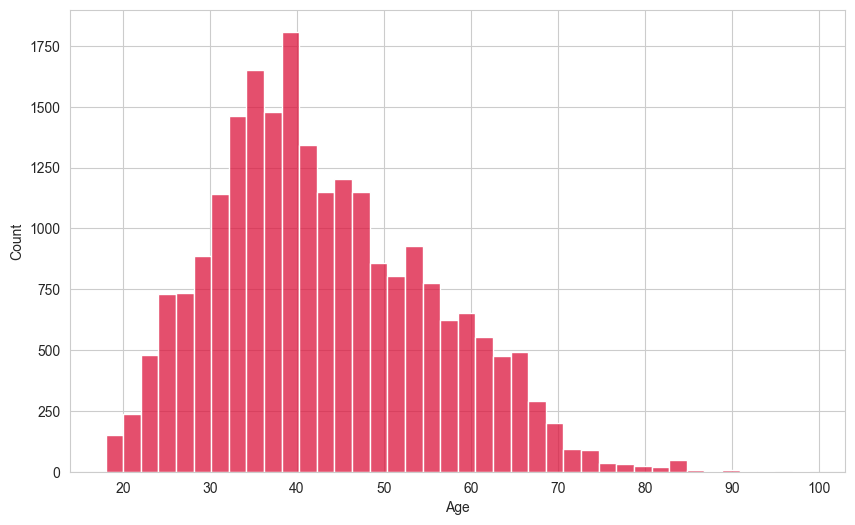

In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(df, x='Age', bins=40, color='crimson')

C:\Users\nuhme\AppData\Local\Temp\ipykernel_48844\433020311.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Rating', data=df, palette='Spectral')


Text(0.5, 1.0, 'Rating Distribution')

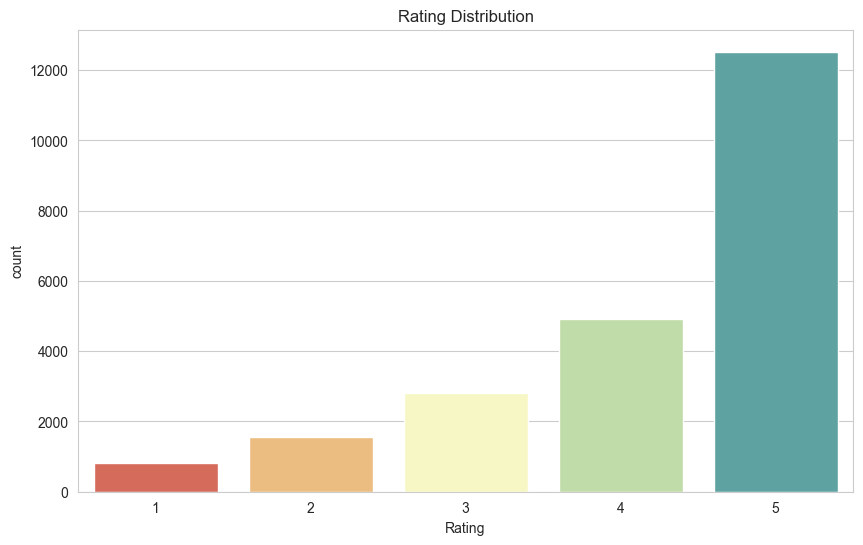

In [10]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Rating', data=df, palette='Spectral')
plt.title('Rating Distribution')

C:\Users\nuhme\AppData\Local\Temp\ipykernel_48844\3446394013.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Rating', y='Word_Count', data=df, palette='Spectral')


<Axes: xlabel='Rating', ylabel='Word_Count'>

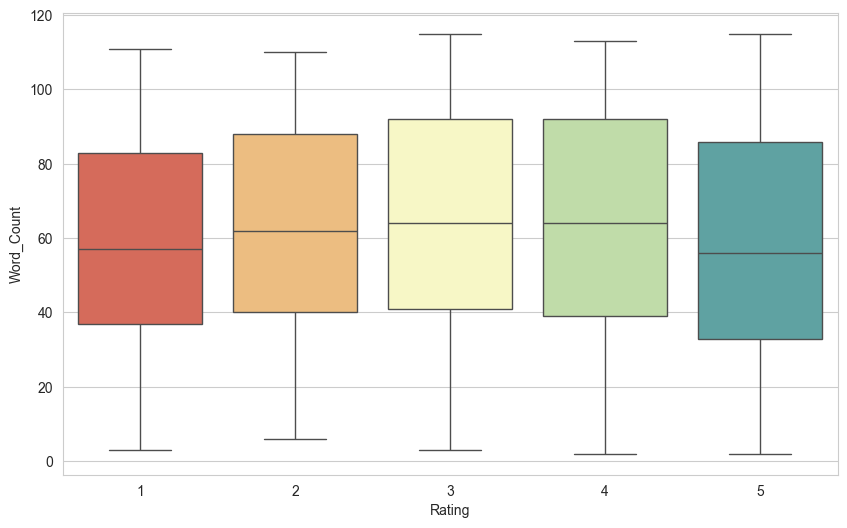

In [11]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Rating', y='Word_Count', data=df, palette='Spectral')

<Axes: xlabel='Count', ylabel='Class Name'>

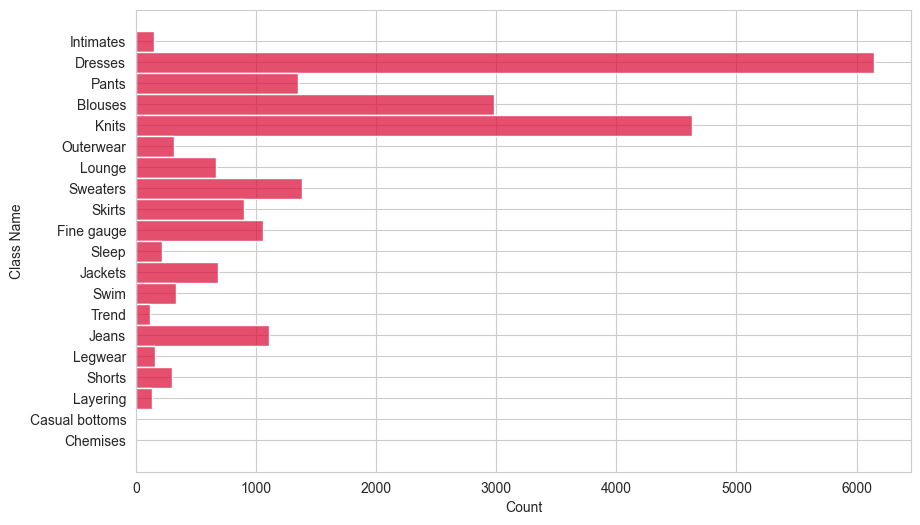

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(df, y='Class Name', color='crimson')

**Text Preprocessing & Cleaning**

In [13]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

In [14]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nuhme\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\nuhme\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\nuhme\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\nuhme\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [15]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if not isinstance(text, str):
        return ""
    
    text = text.lower()
    
    text = re.sub(r'[^\w\s]', '', text) 
    text = re.sub(r'\d+', '', text)     
    
    words = text.split()
    
    cleaned_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    
    return " ".join(cleaned_words)

In [16]:
df['Cleaned_Text'] = df['Full_Text'].apply(clean_text)

df.drop('Clothing ID', axis=1, inplace=True)


In [17]:
display(df[['Full_Text', 'Cleaned_Text']].head(5))

,Full_Text,Cleaned_Text
0,Absolutely wonderful - silky and sexy and com...,absolutely wonderful silky sexy comfortable
1,Love this dress! it's sooo pretty. i happen...,love dress sooo pretty happened find store im ...
2,Some major design flaws I had such high hopes ...,major design flaw high hope dress really wante...
3,"My favorite buy! I love, love, love this jumps...",favorite buy love love love jumpsuit fun flirt...
4,Flattering shirt This shirt is very flattering...,flattering shirt shirt flattering due adjustab...


In [18]:
all_words = " ".join(df['Cleaned_Text'])

wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='magma').generate(all_words)

Text(0.5, 1.0, 'En Çok Kullanılan Kelimeler (Temizlik Sonrası)')

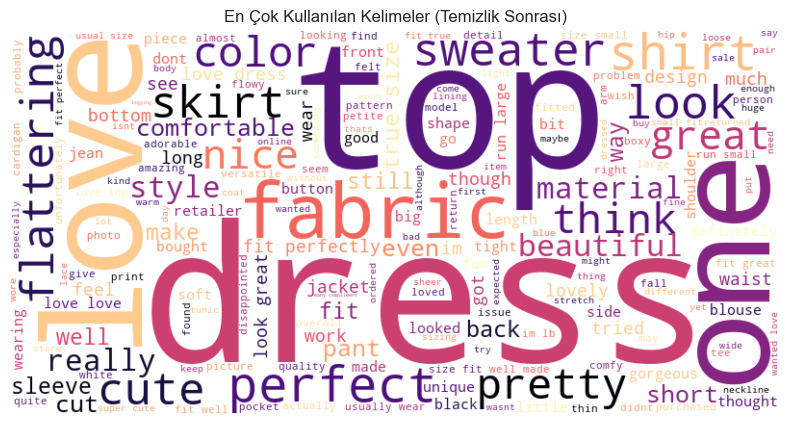

In [19]:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("En Çok Kullanılan Kelimeler (Temizlik Sonrası)")


**Feature Extraction**

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

In [21]:
df_model = df[df['Rating'] != 3].copy()

In [22]:
# 4 and 5 rating -> 1(Positive)
# 1 and 2 rating -> 0(Negative)
df_model['Sentiment'] = df_model['Rating'].apply(lambda x: 1 if x > 3 else 0)

In [23]:
print(df_model['Sentiment'].value_counts())

Sentiment
1    17435
0     2370
Name: count, dtype: int64


In [24]:
X = df_model['Cleaned_Text']
y = df_model['Sentiment']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [26]:
print(X_train.shape)
print(X_test.shape)

(15844,)
(3961,)


In [27]:
vectorizer = TfidfVectorizer(max_features=5000)

In [28]:
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [29]:
print("\nVektörleştirme tamamlandı!")
print(f"Eğitim matrisi boyutu: {X_train_vec.shape}")


Vektörleştirme tamamlandı!
Eğitim matrisi boyutu: (15844, 5000)


**Model Training**

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [31]:
# class_weight='balanced': Dengesiz veri seti için kritik parametre!
# max_iter=1000: Modelin yakınsaması (converge) için iterasyon sınırını artırdık.
log_model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
log_model.fit(X_train_vec, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [32]:
# --- ADIM 2: Tahmin ve Değerlendirme ---
y_pred = log_model.predict(X_test_vec)

In [33]:
# Skorları yazdıralım
print(f"Model Doğruluğu (Accuracy): {accuracy_score(y_test, y_pred):.4f}")
print("\n--- Detaylı Sınıflandırma Raporu ---")
print(classification_report(y_test, y_pred, target_names=['Negatif (0)', 'Pozitif (1)']))

Model Doğruluğu (Accuracy): 0.9321

--- Detaylı Sınıflandırma Raporu ---
              precision    recall  f1-score   support

 Negatif (0)       0.66      0.89      0.76       474
 Pozitif (1)       0.98      0.94      0.96      3487

    accuracy                           0.93      3961
   macro avg       0.82      0.91      0.86      3961
weighted avg       0.95      0.93      0.94      3961



In [34]:
# --- ADIM 3: Karmaşıklık Matrisi (Confusion Matrix) ---
# Modelin nerede hata yaptığını gözle görelim.
cm = confusion_matrix(y_test, y_pred)

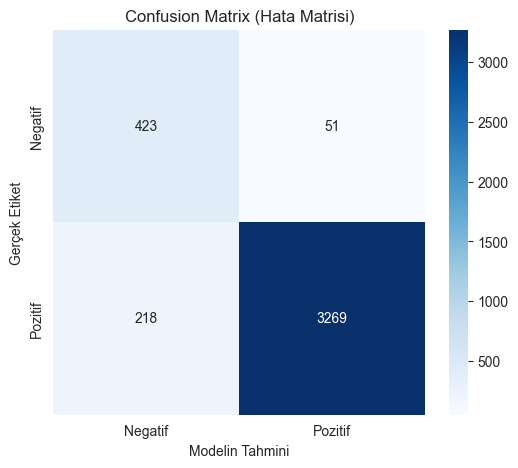

In [35]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negatif', 'Pozitif'], 
            yticklabels=['Negatif', 'Pozitif'])
plt.ylabel('Gerçek Etiket')
plt.xlabel('Modelin Tahmini')
plt.title('Confusion Matrix (Hata Matrisi)')
plt.show()

Model Testing

In [36]:
import joblib

In [37]:
# --- ADIM 1: Modeli ve Vectorizer'ı Kaydetme ---
# Modeli ve metni sayılara çeviren vectorizer'ı kaydediyoruz.
# İleride bir web sitesine entegre etmek istersek sadece bu iki dosyayı kullanacağız.
joblib.dump(log_model, 'sentiment_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
print("✅ Model ve Vectorizer başarıyla diske kaydedildi ('sentiment_model.pkl', 'tfidf_vectorizer.pkl')\n")

✅ Model ve Vectorizer başarıyla diske kaydedildi ('sentiment_model.pkl', 'tfidf_vectorizer.pkl')



In [39]:
# --- ADIM 2: Canlı Test Fonksiyonu (Inference) ---
def predict_review_sentiment(custom_review):
    # 1. Metni temizle (Önceki yazdığımız clean_text fonksiyonunu kullanır)
    cleaned_review = clean_text(custom_review)
    
    # 2. Vektörleştir (Eğitilmiş vectorizer'ı kullan, FIT YAPMA SADECE TRANSFORM YAP)
    vectorized_review = vectorizer.transform([cleaned_review])
    
    # 3. Tahmin yap
    prediction = log_model.predict(vectorized_review)[0]
    probabilities = log_model.predict_proba(vectorized_review)[0] # [Negatif_olma_ihtimali, Pozitif_olma_ihtimali]
    
    # 4. Sonuçları formatla
    sentiment = "Pozitif 🟢" if prediction == 1 else "Negatif 🔴"
    confidence = max(probabilities) * 100
    
    print("-" * 50)
    print(f"Yorum: '{custom_review}'")
    print(f"Tahmin: {sentiment}")
    print(f"Güven Skoru (Confidence): %{confidence:.2f}")

In [40]:
# --- ADIM 3: Test Vakti! ---
# Kendi cümlelerimizi verip modelin ne tepki verdiğini görelim.

predict_review_sentiment("I absolutely love this dress! The fabric is so soft and the fit is perfect.")
predict_review_sentiment("Terrible quality. The zipper broke after one wash and it looks cheap.")
predict_review_sentiment("It's an okay shirt, but the color is a bit different from the picture.")
predict_review_sentiment("Not what I expected, I will return this immediately.")

--------------------------------------------------
Yorum: 'I absolutely love this dress! The fabric is so soft and the fit is perfect.'
Tahmin: Pozitif 🟢
Güven Skoru (Confidence): %98.99
--------------------------------------------------
Yorum: 'Terrible quality. The zipper broke after one wash and it looks cheap.'
Tahmin: Negatif 🔴
Güven Skoru (Confidence): %99.41
--------------------------------------------------
Yorum: 'It's an okay shirt, but the color is a bit different from the picture.'
Tahmin: Negatif 🔴
Güven Skoru (Confidence): %63.33
--------------------------------------------------
Yorum: 'Not what I expected, I will return this immediately.'
Tahmin: Negatif 🔴
Güven Skoru (Confidence): %98.37


Extra Visualizations

The **"Trend"** department has by far the highest negative review ratio (approximately 30-35%). While other departments maintain a more stable customer satisfaction rate (around the 15-20% band), there is a issue within the Trend department.

C:\Users\nuhme\AppData\Local\Temp\ipykernel_48844\409494757.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Duygu', loc='upper right')


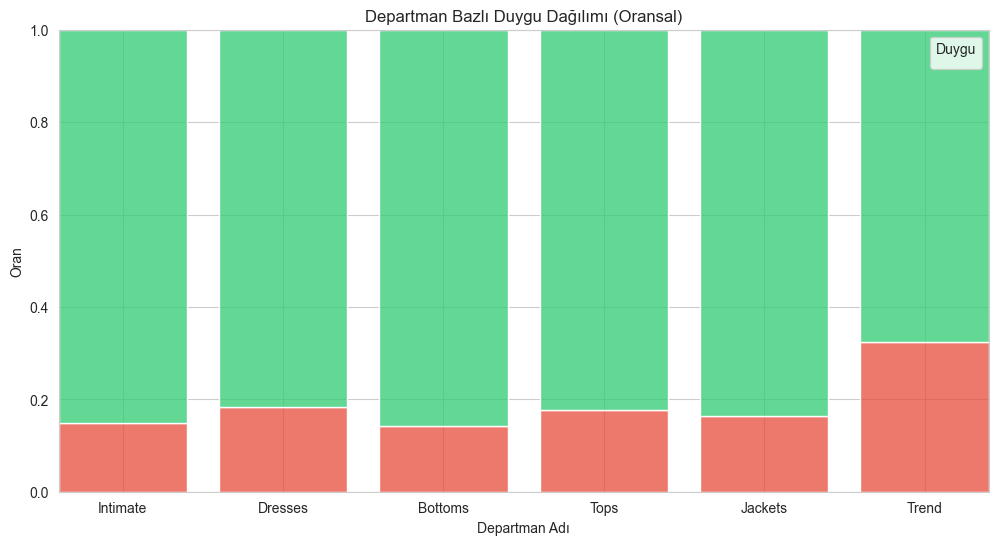

In [42]:
# --- ADIM 8.1: Segmented Sentiment Analizi (Departman Bazlı) ---
# X_all_vec'i daha önce tanımladıysak tekrar çalıştırmaya gerek yok ama 
# garanti olsun diye baştan alıyoruz.

X_all_vec = vectorizer.transform(df_model['Cleaned_Text'])
df_model['Predicted_Sentiment'] = log_model.predict(X_all_vec)

# 1 ve 0'ları görselde güzel dursun diye metne çeviriyoruz
df_model['Sentiment_Label'] = df_model['Predicted_Sentiment'].map({1: 'Pozitif', 0: 'Negatif'})

plt.figure(figsize=(12, 6))
# multiple="fill" parametresi ile barları %100'e tamamlayarak oranları gösteriyoruz
sns.histplot(data=df_model, x='Department Name', hue='Sentiment_Label', 
             multiple="fill", shrink=0.8, palette={'Pozitif': '#2ecc71', 'Negatif': '#e74c3c'})

plt.title('Departman Bazlı Duygu Dağılımı (Oransal)')
plt.ylabel('Oran')
plt.xlabel('Departman Adı')
plt.legend(title='Duygu', loc='upper right')
plt.show()

The most frequently highlighted words in the negative word cloud are **"size"**, **"small"**, **"color"**, and **"fabric"**. In terms of product groups, words like **"top"**, **"shirt"**, and **"dress"** stand out significantly.

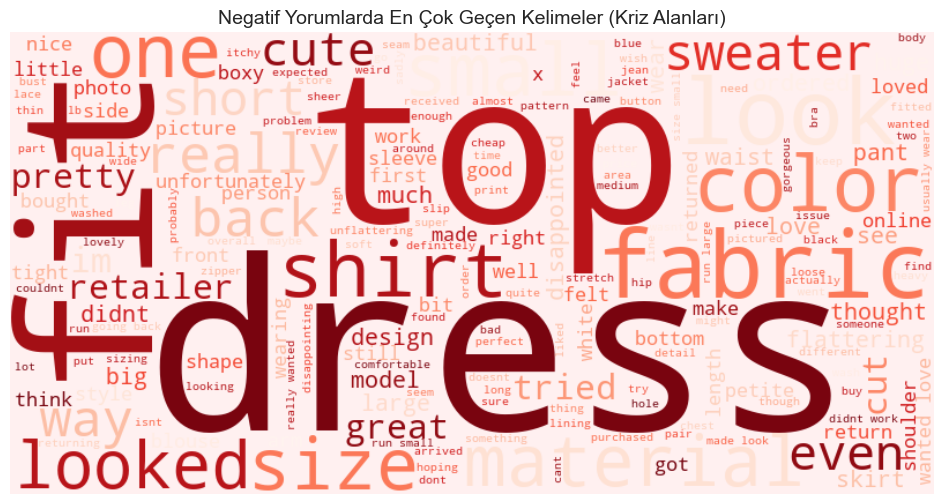

In [43]:
# --- ADIM 8.2: Sadece Negatif Yorumlar İçin Kelime Bulutu ---
negative_reviews = df_model[df_model['Predicted_Sentiment'] == 0]['Cleaned_Text']
negative_text = " ".join(negative_reviews)

neg_wordcloud = WordCloud(width=800, height=400, background_color='#FFF0F0', colormap='Reds').generate(negative_text)

plt.figure(figsize=(12, 6))
plt.imshow(neg_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Negatif Yorumlarda En Çok Geçen Kelimeler (Kriz Alanları)", fontsize=14)
plt.show()

According to the boxplot (log scale), the median "Positive Feedback Count" (helpful votes from other users) for **Negative** reviews is noticeably higher than that of positive reviews.

C:\Users\nuhme\AppData\Local\Temp\ipykernel_48844\2087476421.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x='Sentiment_Label', y='Positive Feedback Count',


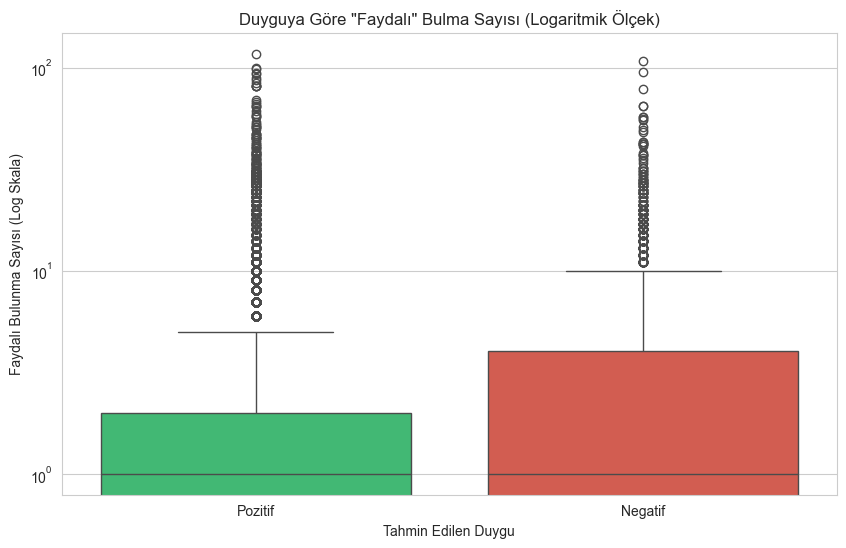

In [44]:
# --- ADIM 8.3: Duyguya Göre 'Faydalı' (Positive Feedback Count) Puanı ---
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_model, x='Sentiment_Label', y='Positive Feedback Count', 
            palette={'Pozitif': '#2ecc71', 'Negatif': '#e74c3c'})

plt.yscale('log') # Y eksenini logaritmik yapıyoruz çünkü bazı yorumlar çok fazla puan almış, grafiği ezer.
plt.title('Duyguya Göre "Faydalı" Bulma Sayısı (Logaritmik Ölçek)')
plt.xlabel('Tahmin Edilen Duygu')
plt.ylabel('Faydalı Bulunma Sayısı (Log Skala)')
plt.show()